# Entrenamiento modelo predicción de salario

In [28]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/interim/df_merged.csv')
df = df.dropna(subset=['experiencia'])
df.drop(columns=['Rango_Salarial','Salario_medio','años_experiencia','modalidad','beneficios'], inplace=True)
df = df.drop(index=df[df['tipo_de_empleo'] == 'Voluntariado'].index)
df = df.drop(index=df[df['sector'] == 'Bienes raíces'].index)

In [29]:
df.shape

(19929, 6)

In [30]:
df['experiencia'].value_counts()

experiencia
junior    7174
intern    6831
senior    5924
Name: count, dtype: int64

In [31]:
df['experiencia'] = df['experiencia'].replace({'intern': 0, 'junior': 1, 'senior': 2})

In [32]:
df.head()

,experiencia,formación_académica,sector,tipo_de_empleo,Ciudad,Titulo_Habilidades
0,1,Grado Universitario,"Salud, Farmacia y Tecnología Médica",Media jornada,Madrid,FISIOTERAPEUTA NEUROLÓGICO Fisioterapia neurol...
1,1,Ninguna,Servicios,Jornada completa,Madrid,Comercial puerta fría - Sector banca digital C...
2,1,Grado Universitario,Economía y política,Jornada completa,Madrid,"Profesora/a de Lengua 2ºESO Profesor, enseñanz..."
3,2,Ninguna,Transporte y Logística,NaN,Madrid,"Direct Entry Captain - Pilot Piloto, experienc..."
4,0,Ninguna,Economía y política,Jornada completa,Madrid,Promotor/a - Encuestador/a de Educación comuni...


## 1. Declarar X e y

In [33]:
X = df.drop(columns=['experiencia'])
y = df['experiencia']

## 2. Dividir en train y test

In [34]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## 3. Feature Engineering

### Valores faltantes

In [35]:
X_train.isnull().sum()

formación_académica       0
sector                    0
tipo_de_empleo         4887
Ciudad                  228
Titulo_Habilidades        0
dtype: int64

Por ahora voy a mantener los nulos, ya que modelos como XGBoost o Random Forest pueden trabajar con valores nulos.

### Encode variables categoricas

In [36]:
X_train[['formación_académica','sector','tipo_de_empleo','Ciudad']]

,formación_académica,sector,tipo_de_empleo,Ciudad
4671,Grado Universitario,Energía y medio ambiente,Jornada completa,Granada
31241,Ninguna,Tecnología y telecomunicaciones,Temporal,Madrid
2337,Ninguna,Deportes y recreación,Media jornada,España
11851,Ninguna,"Salud, Farmacia y Tecnología Médica",Jornada completa,Madrid
13646,Grado Universitario,"Salud, Farmacia y Tecnología Médica",Jornada completa,Tarragona
...,...,...,...,...
2660,Ninguna,Servicios,NaN,España
21122,Ninguna,Energía y medio ambiente,NaN,Madrid
30068,Ninguna,"Salud, Farmacia y Tecnología Médica",Media jornada,Alicante
3229,Ninguna,Transporte y Logística,Jornada completa,España


In [37]:
pd.get_dummies(X_train['formación_académica'], prefix='formacion', drop_first=True, dummy_na=True).astype(int).head()

,formacion_FP Medio,formacion_FP Superior,formacion_Grado Universitario,formacion_Ninguna,formacion_Postgrado,formacion_nan
4671,0,0,1,0,0,0
31241,0,0,0,1,0,0
2337,0,0,0,1,0,0
11851,0,0,0,1,0,0
13646,0,0,1,0,0,0


In [38]:
pd.get_dummies(X_train['sector'], prefix='sector', drop_first=True).astype(int).head()

,sector_Bienes de consumo,sector_Comercio electrónico,sector_Comercio minorista y comercio,sector_Construcción,sector_Deportes y recreación,sector_Economía y política,sector_Energía y medio ambiente,sector_Finanzas y seguros,sector_Internet,sector_Medios de comunicación,sector_Metales y electrónica,sector_Productos químicos y recursos,sector_Publicidad y Marketing,"sector_Salud, Farmacia y Tecnología Médica",sector_Servicios,sector_Sociedad,sector_Tecnología y telecomunicaciones,sector_Transporte y Logística,"sector_Viajes, turismo y hostelería"
4671,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
31241,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2337,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
11851,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
13646,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0


In [39]:
pd.get_dummies(X_train['tipo_de_empleo'], prefix='tipo_empleo', drop_first=True, dummy_na=True).astype(int).head()

,tipo_empleo_Jornada completa,tipo_empleo_Media jornada,tipo_empleo_Otro,tipo_empleo_Prácticas,tipo_empleo_Temporal,tipo_empleo_nan
4671,1,0,0,0,0,0
31241,0,0,0,0,1,0
2337,0,1,0,0,0,0
11851,1,0,0,0,0,0
13646,1,0,0,0,0,0


In [40]:
X_train = pd.concat([X_train.drop(columns=['formación_académica','sector','tipo_de_empleo','Ciudad']),
                     pd.get_dummies(X_train['formación_académica'], prefix='formacion', drop_first=True, dummy_na=True).astype(int),
                     pd.get_dummies(X_train['sector'], prefix='sector', drop_first=True).astype(int),
                     pd.get_dummies(X_train['tipo_de_empleo'], prefix='tipo_empleo', drop_first=True, dummy_na=True).astype(int)], axis=1)

In [41]:
X_train.head()

,Titulo_Habilidades,formacion_FP Medio,formacion_FP Superior,formacion_Grado Universitario,formacion_Ninguna,formacion_Postgrado,formacion_nan,sector_Bienes de consumo,sector_Comercio electrónico,sector_Comercio minorista y comercio,...,sector_Sociedad,sector_Tecnología y telecomunicaciones,sector_Transporte y Logística,"sector_Viajes, turismo y hostelería",tipo_empleo_Jornada completa,tipo_empleo_Media jornada,tipo_empleo_Otro,tipo_empleo_Prácticas,tipo_empleo_Temporal,tipo_empleo_nan
4671,Junior Business - Contabilidad y Finanzas Titu...,0,0,1,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
31241,CASTING PARA VIDEO PROMOCIONAL EN RRSS Habilid...,0,0,0,1,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,0
2337,Peón/a almacén y ayuda a carga / descarga PRL ...,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
11851,"Consultor Senior Estrategia, Salud Consultoría...",0,0,0,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
13646,FISIOTERAPEUTA CENTRO RESIDENCIAL Fisioterapia...,0,0,1,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


In [42]:
X_test = pd.concat([X_test.drop(columns=['formación_académica','sector','tipo_de_empleo','Ciudad']),
                     pd.get_dummies(X_test['formación_académica'], prefix='formacion', drop_first=True, dummy_na=True).astype(int),
                     pd.get_dummies(X_test['sector'], prefix='sector', drop_first=True).astype(int),
                     pd.get_dummies(X_test['tipo_de_empleo'], prefix='tipo_empleo', drop_first=True, dummy_na=True).astype(int)], axis=1)

In [43]:
#Separo la columna de texto para vectorizar después
X_train_habilidades = X_train[['Titulo_Habilidades']]
X_test_habilidades = X_test[['Titulo_Habilidades']]
X_train = X_train.drop(columns=['Titulo_Habilidades'])
X_test = X_test.drop(columns=['Titulo_Habilidades'])

## 4. Feature Scaling

In [17]:
from sklearn.preprocessing import MinMaxScaler
import joblib
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

X_train_scaled.reset_index(drop=True, inplace=True)
X_test_scaled.reset_index(drop=True, inplace=True)

joblib.dump(scaler, '../artifacts/seniority/scaler.joblib')

['../artifacts/seniority/scaler.joblib']

### Generar embeddings

In [18]:
# guardo los textos preparados en una lista para generar los embeddings
textos_train = ["passage: " + texto for texto in X_train_habilidades['Titulo_Habilidades'].tolist()] 
textos_test = ["passage: " + texto for texto in X_test_habilidades['Titulo_Habilidades'].tolist()] 
#passage es necesario para que el modelo de embeddings sepa que es un texto a procesar

from sentence_transformers import SentenceTransformer
model = SentenceTransformer('intfloat/multilingual-e5-large', device='cuda') #cargar el modelo SBERT (para mi tarjeta gráfica de los que mejor funciona)

# Generar los embeddings para los textos 
matriz_embeddings_train = model.encode(
    textos_train, 
    show_progress_bar=True, 
    batch_size=64 
)

matriz_embeddings_test = model.encode(
    textos_test, 
    show_progress_bar=True, 
    batch_size=64 
)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Batches:   0%|          | 0/250 [00:00<?, ?it/s]

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Ahora voy a aplicar PCA para reducir las 1024 dimensiones.

In [44]:
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(matriz_embeddings_train)

#Calcular la varianza explicada acumulada
varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)

# Determinar el número de componentes necesarios para explicar al menos el 70% de la varianza
n_componentes = np.argmax(varianza_acumulada >= 0.70) + 1
print(n_componentes)

joblib.dump(pca, '../artifacts/seniority/pca.joblib')

83


['../artifacts/seniority/pca.joblib']

Puedo reducir el número de dimensiones a 83 y mantener un 70% de la varianza explicada. 

In [45]:
pca = PCA(n_components=83, random_state=42)
embeddings_reducidos_train = pca.fit_transform(matriz_embeddings_train)
X_train_embeddings = pd.DataFrame(embeddings_reducidos_train, columns=[f'PC{i+1}' for i in range(embeddings_reducidos_train.shape[1])])

embeddings_reducidos_test = pca.transform(matriz_embeddings_test)
X_test_embeddings = pd.DataFrame(embeddings_reducidos_test, columns=[f'PC{i+1}' for i in range(embeddings_reducidos_test.shape[1])])

X_train_embeddings.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC74,PC75,PC76,PC77,PC78,PC79,PC80,PC81,PC82,PC83
0,0.095838,0.004715,-0.000705,-0.017444,-0.091647,0.022043,-0.034559,-0.063299,-0.057362,-0.025406,...,-0.006630,0.013998,-0.061288,-0.023981,0.013495,0.008901,-0.031939,0.037550,0.014007,0.024334
1,-0.086042,0.023519,0.115220,-0.045402,0.194412,0.142108,-0.139429,-0.072461,0.078062,0.044067,...,-0.003344,0.003684,-0.001112,-0.001306,-0.000145,-0.000065,0.002129,-0.000187,0.006392,-0.001801
2,-0.129844,0.042118,-0.025341,-0.006485,0.044075,-0.042505,-0.003352,0.049469,0.013876,0.003508,...,0.008221,0.018245,-0.004277,-0.010607,0.028212,0.014289,0.006026,0.045644,0.007993,-0.019695
3,-0.149793,-0.136181,-0.000801,0.063850,-0.103372,0.037563,0.024254,-0.042579,0.059658,0.022162,...,0.002070,0.022901,-0.003126,0.022119,0.006510,-0.003844,0.000282,0.019277,0.010565,0.007538
4,0.113312,0.059727,-0.029990,0.006336,0.046006,0.008385,0.037121,-0.064870,-0.002449,0.067908,...,0.010846,0.014115,0.009356,0.022844,0.033910,0.008301,-0.029247,-0.027100,0.005871,0.021062


In [46]:
X_train = pd.concat([X_train_scaled, X_train_embeddings], axis=1)
X_test = pd.concat([X_test_scaled, X_test_embeddings], axis=1)

In [47]:
X_train.head()

,formacion_FP Medio,formacion_FP Superior,formacion_Grado Universitario,formacion_Ninguna,formacion_Postgrado,formacion_nan,sector_Bienes de consumo,sector_Comercio electrónico,sector_Comercio minorista y comercio,sector_Construcción,...,PC74,PC75,PC76,PC77,PC78,PC79,PC80,PC81,PC82,PC83
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.006630,0.013998,-0.061288,-0.023981,0.013495,0.008901,-0.031939,0.037550,0.014007,0.024334
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.003344,0.003684,-0.001112,-0.001306,-0.000145,-0.000065,0.002129,-0.000187,0.006392,-0.001801
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.008221,0.018245,-0.004277,-0.010607,0.028212,0.014289,0.006026,0.045644,0.007993,-0.019695
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.002070,0.022901,-0.003126,0.022119,0.006510,-0.003844,0.000282,0.019277,0.010565,0.007538
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.010846,0.014115,0.009356,0.022844,0.033910,0.008301,-0.029247,-0.027100,0.005871,0.021062


## 5. Entrenamiento de modelos

In [48]:
# Arreglar nombre de columnas para evitar problemas con los modelos
X_train.columns = X_train.columns.str.replace(',', '_')
X_test.columns = X_test.columns.str.replace(',', '_')

In [49]:
sets_posibles = [
    list(X_train.columns),
    list(X_train.drop(columns=['tipo_empleo_Jornada completa','tipo_empleo_Media jornada','tipo_empleo_Otro','tipo_empleo_Prácticas','tipo_empleo_Temporal','tipo_empleo_nan']).columns),
]

In [50]:
import scipy as sp
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
import sklearn.metrics as metrics
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc, roc_auc_score

In [54]:
# XGBoost, entrenado con GPU para acelerar el entrenamiento
xgb_model = xgb.XGBClassifier(random_state=42,
                              objective='multi:softprob',
                              eval_metric='mlogloss',
                              num_class=y_train.nunique(),
                              tree_method='hist',
                              device='cuda')

param_grid = {"n_estimators": [50, 100],
              'max_depth': sp.stats.randint(3, 6),
              'learning_rate': sp.stats.uniform(0.01, 0.1),
              'subsample': sp.stats.uniform(0.6, 0.3),
              'colsample_bytree': sp.stats.uniform(0.6, 0.3),
              'min_child_weight': sp.stats.randint(5, 20),
              'gamma': sp.stats.uniform(2, 6),
              'reg_alpha': sp.stats.uniform(1, 10),
              'reg_lambda': sp.stats.uniform(5, 15)
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
xgb_model = RandomizedSearchCV(xgb_model,
                               param_grid,
                               n_iter=25,
                               cv=cv,
                               random_state=42,
                               scoring='f1_macro',
                               verbose=3
                               )


# LightGBM
lgb_model = lgb.LGBMClassifier(random_state=42,
                               objective='multiclass',
                               num_class=y_train.nunique(),
                               class_weight='balanced',
                               device_type='gpu')

param_grid = {"n_estimators": [50, 100],
              'max_depth': sp.stats.randint(3, 6),
              'learning_rate': sp.stats.uniform(0.01, 0.1),
              'num_leaves': sp.stats.randint(15, 80),
              'min_child_samples': sp.stats.randint(5, 50),
              'subsample': sp.stats.uniform(0.6, 0.3),
              'colsample_bytree': sp.stats.uniform(0.6, 0.3),
              'reg_alpha': sp.stats.uniform(1, 10),
              'reg_lambda': sp.stats.uniform(5, 15)
}

lgb_model = RandomizedSearchCV(lgb_model,
                               param_grid,
                               n_iter=25,
                               cv=cv,
                               random_state=42,
                               scoring='f1_macro',
                               verbose=3
                               )


In [56]:
from pathlib import Path
import joblib
from sklearn.metrics import cohen_kappa_score

modelos = [xgb_model,lgb_model]
score_df = pd.DataFrame()
models_dir = Path('../models/seniority')
models_dir.mkdir(parents=True, exist_ok=True)

for i, features in enumerate(sets_posibles):
    X_train_fit = X_train[features]
    X_test_fit = X_test[features]
    print(f'Set : {i+1} con {len(features)} features')
    for modelo in modelos:
        model_name = modelo.estimator.__class__.__name__
        model_path = models_dir / f'set_{i+1}_{model_name}.joblib'

        if model_path.exists():
            print(f'  Saltando {model_name} en set {i+1}: ya existe {model_path.name}')
            modelo = joblib.load(model_path)
            y_pred_train = modelo.predict(X_train_fit)
            y_pred_proba = modelo.predict_proba(X_test_fit)
            y_pred_test = modelo.predict(X_test_fit)

            accuracy_test = accuracy_score(y_test, y_pred_test)
            accuracy_train = accuracy_score(y_train, y_pred_train)

            auc_roc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='macro', labels=modelo.classes_)
            #average 'macro' para dar igual peso a cada clase independientemente de su frecuencia

            #Kappa de Cohen
            kappa_test = cohen_kappa_score(y_test, y_pred_test)
            # kappa para evaluar el acuerdo entre las predicciones y las etiquetas reales, teniendo en cuenta lo que podría ocurrir por azar

            new_scores = pd.DataFrame({
                "Modelo": [model_name],
                "Feature set": [f'Set : {i+1} con {len(features)} features'],
                "Accuracy test": [accuracy_test],
                "Accuracy train": [accuracy_train],
                "AUC-ROC": [auc_roc],
                "Kappa": [kappa_test]
            })
            score_df = pd.concat([score_df, new_scores], ignore_index=True)
            continue

        try:
            print(model_name) #imprimir el nombre del modelo
            modelo.fit(X_train_fit, y_train)

            # Guardar el modelo
            joblib.dump(modelo.best_estimator_, model_path)

            # Hacer predicciones
            y_pred_train = modelo.predict(X_train_fit)
            y_pred_proba = modelo.predict_proba(X_test_fit)
            y_pred_test = modelo.predict(X_test_fit)

            #Calcular accuracy
            accuracy_test = accuracy_score(y_test, y_pred_test)
            accuracy_train = accuracy_score(y_train, y_pred_train)

            #Calcular AUC-ROC
            auc_roc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='macro', labels=modelo.classes_) 

            #Kappa de Cohen
            kappa_test = cohen_kappa_score(y_test, y_pred_test)

            #Crear dataframe
            new_scores = pd.DataFrame({
                "Modelo": [model_name],
                "Feature set": [f'Set : {i+1} con {len(features)} features'],
                "Accuracy test": [accuracy_test],
                "Accuracy train": [accuracy_train],
                "AUC-ROC": [auc_roc],
                "Kappa": [kappa_test]
            })
            score_df = pd.concat([score_df, new_scores], ignore_index=True)
        except Exception as exc:
            print(f'  Error en {model_name} para set {i+1}: {exc}')
            continue
score_df

Set : 1 con 114 features
XGBClassifier
Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END colsample_bytree=0.7123620356542087, gamma=7.704285838459497, learning_rate=0.0831993941811405, max_depth=3, min_child_weight=9, n_estimators=50, reg_alpha=5.458327528535912, reg_lambda=6.499623737270044, subsample=0.7377746675897601;, score=0.685 total time=   0.4s
[CV 2/5] END colsample_bytree=0.7123620356542087, gamma=7.704285838459497, learning_rate=0.0831993941811405, max_depth=3, min_child_weight=9, n_estimators=50, reg_alpha=5.458327528535912, reg_lambda=6.499623737270044, subsample=0.7377746675897601;, score=0.698 total time=   0.2s
[CV 3/5] END colsample_bytree=0.7123620356542087, gamma=7.704285838459497, learning_rate=0.0831993941811405, max_depth=3, min_child_weight=9, n_estimators=50, reg_alpha=5.458327528535912, reg_lambda=6.499623737270044, subsample=0.7377746675897601;, score=0.678 total time=   0.2s
[CV 4/5] END colsample_bytree=0.7123620356542087, gamma=7.7

,Modelo,Feature set,Accuracy test,Accuracy train,AUC-ROC,Kappa
0,XGBClassifier,Set : 1 con 114 features,0.710487,0.798909,0.883494,0.562568
1,LGBMClassifier,Set : 1 con 114 features,0.720020,0.837546,0.887349,0.577821
2,XGBClassifier,Set : 2 con 108 features,0.702960,0.804742,0.876262,0.551310
3,LGBMClassifier,Set : 2 con 108 features,0.697441,0.784670,0.874757,0.543969


El Kappa es algo bajo, mide el grado de acuerdo entre dos evaluadores o instrumentos, descontando el acierto por azar. Entre 0.4 y 0.6 tiene una concordancia moderada, supera los aciertos que habrían tenido por azar, es aceptable pero mejorable.

In [58]:
score_df.sort_values(by='AUC-ROC', ascending=False)

,Modelo,Feature set,Accuracy test,Accuracy train,AUC-ROC,Kappa
1,LGBMClassifier,Set : 1 con 114 features,0.720020,0.837546,0.887349,0.577821
0,XGBClassifier,Set : 1 con 114 features,0.710487,0.798909,0.883494,0.562568
2,XGBClassifier,Set : 2 con 108 features,0.702960,0.804742,0.876262,0.551310
3,LGBMClassifier,Set : 2 con 108 features,0.697441,0.784670,0.874757,0.543969


## 6. Resultados y explicabilidad

In [61]:
import shap
import matplotlib.pyplot as plt
def resultados(model, X_train_model, X_test_model):
    y_pred_train = model.predict(X_train_model)
    y_pred_proba = model.predict_proba(X_test_model)
    y_pred_test = model.predict(X_test_model)

    auc_roc_test = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='macro',labels=model.classes_)
    auc_roc_train = roc_auc_score(y_train, model.predict_proba(X_train_model), multi_class='ovr', average='macro',labels=model.classes_)

    ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_test,
    cmap=plt.cm.Blues,
    values_format='.0f',
    )
    plt.show()

    display(pd.DataFrame(classification_report(y_test,y_pred_test, output_dict=True)).T)

    print(f'AUC-ROC test: {auc_roc_test:.4f}')
    print(f'AUC-ROC train: {auc_roc_train:.4f}')

    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X_test_model)
    shap.summary_plot(shap_values.values, X_test_model, plot_type="bar")

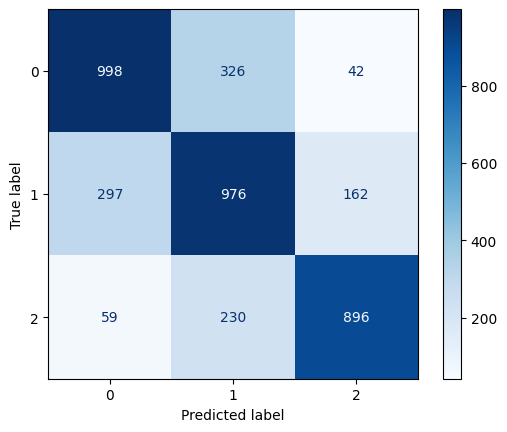

,precision,recall,f1-score,support
0,0.737075,0.730600,0.733824,1366.00000
1,0.637076,0.680139,0.657904,1435.00000
2,0.814545,0.756118,0.784245,1185.00000
accuracy,0.720020,0.720020,0.720020,0.72002
macro avg,0.729566,0.722286,0.725324,3986.00000
weighted avg,0.724106,0.720020,0.721481,3986.00000


AUC-ROC test: 0.8873
AUC-ROC train: 0.9576


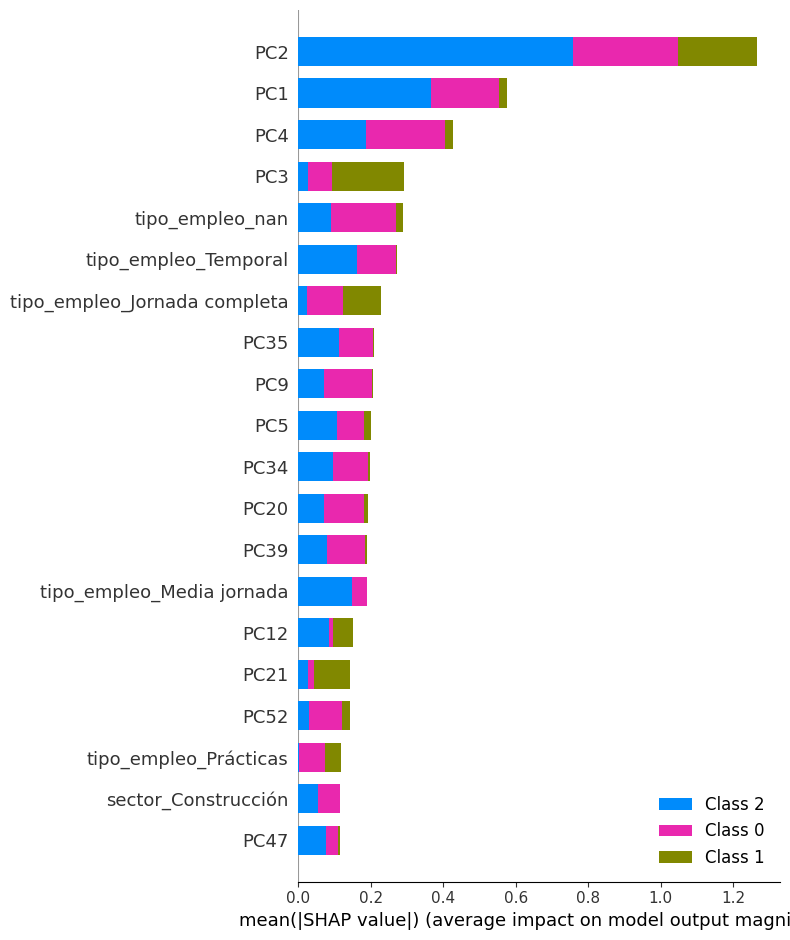

In [62]:
lgbm_set1 = joblib.load('../models/seniority/set_1_LGBMClassifier.joblib')
resultados(lgbm_set1, X_train[sets_posibles[0]], X_test[sets_posibles[0]])

El tipo de empleo nulo lo toma como variable importante, aunque también aparece temporal, jornada completa, media jornada...

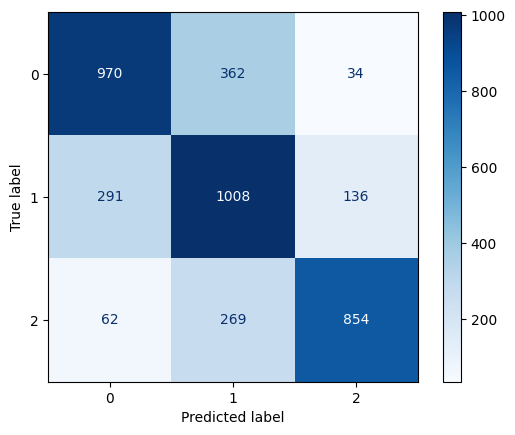

,precision,recall,f1-score,support
0,0.733182,0.710102,0.721458,1366.000000
1,0.615009,0.702439,0.655823,1435.000000
2,0.833984,0.720675,0.773201,1185.000000
accuracy,0.710487,0.710487,0.710487,0.710487
macro avg,0.727392,0.711072,0.716827,3986.000000
weighted avg,0.720606,0.710487,0.713211,3986.000000


AUC-ROC test: 0.8835
AUC-ROC train: 0.9389


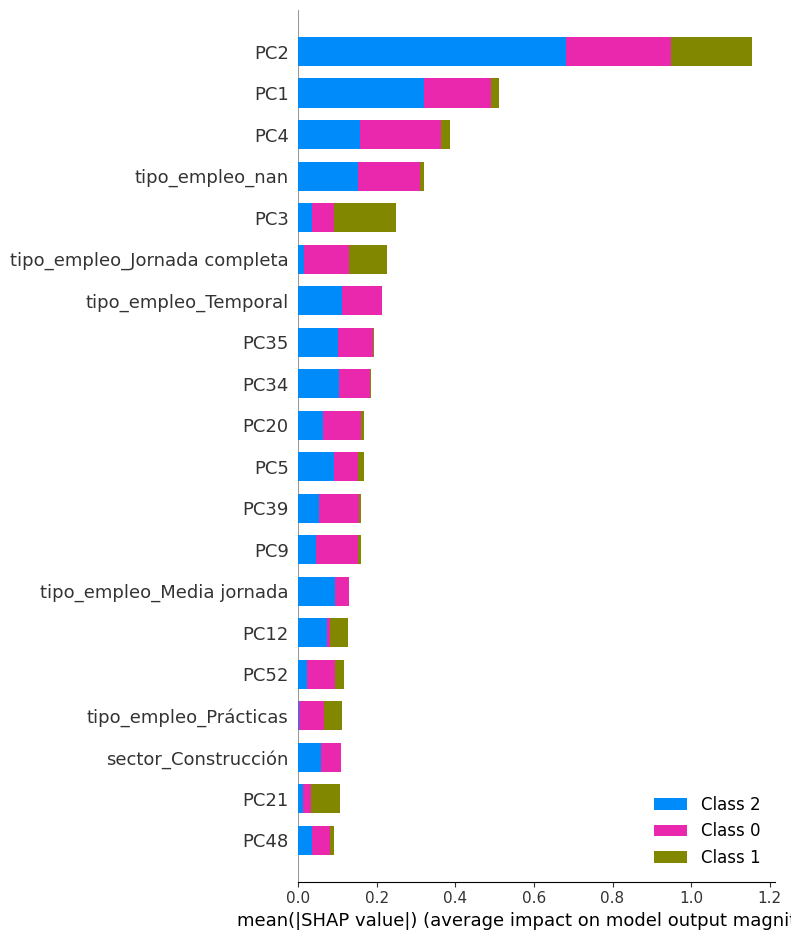

In [63]:
xgb_set1 = joblib.load('../models/seniority/set_1_XGBClassifier.joblib') 
resultados(xgb_set1, X_train[sets_posibles[0]], X_test[sets_posibles[0]])

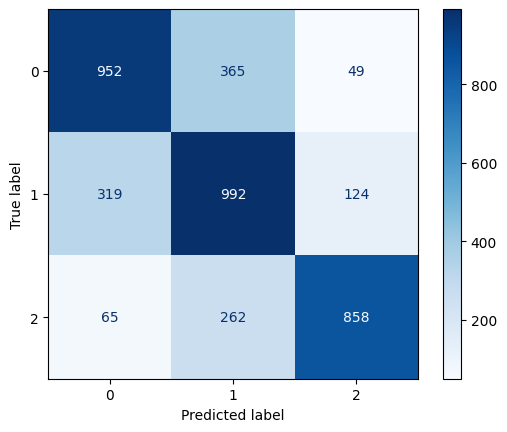

,precision,recall,f1-score,support
0,0.712575,0.696925,0.704663,1366.00000
1,0.612724,0.691289,0.649640,1435.00000
2,0.832202,0.724051,0.774368,1185.00000
accuracy,0.702960,0.702960,0.702960,0.70296
macro avg,0.719167,0.704088,0.709557,3986.00000
weighted avg,0.712191,0.702960,0.705577,3986.00000


AUC-ROC test: 0.8763
AUC-ROC train: 0.9403


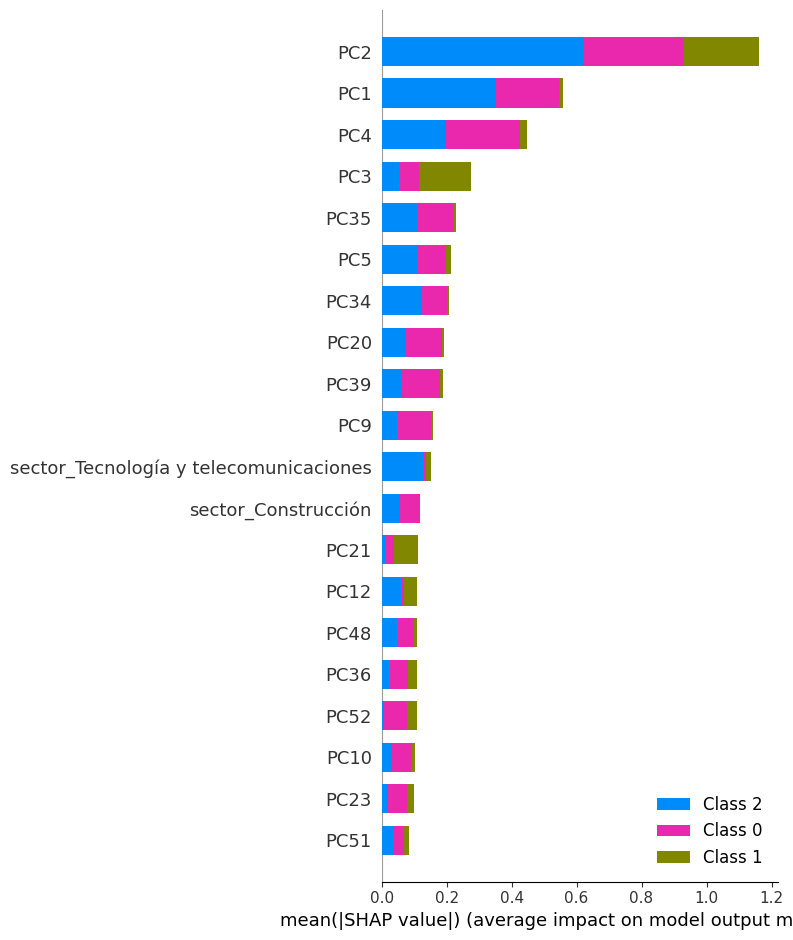

In [64]:
xgb_set2 = joblib.load('../models/seniority/set_2_XGBClassifier.joblib')
resultados(xgb_set2, X_train[sets_posibles[1]], X_test[sets_posibles[1]])

In [31]:
import json
with open('../artifacts/seniority/feature_columns.json', 'w') as f:
    json.dump(list(X_train.columns), f)

En el caso del seniority, aunque toma alta importancia el tipo de empleo como nulo, es una variable que si que aporta más información, por lo que el modelo que mejor me esta funcionando es el LGBM con el set 1.

In [66]:
joblib.dump(lgbm_set1, '../models/seniority/best_model.joblib')

['../models/seniority/best_model.joblib']